#### Exploratory Data Analysis

This exploratory data analysis (EDA) focuses on understanding the patterns, relationships, and key characteristics of the cleaned farm environmental dataset. The dataset was pre-processed to handle missing values, correct inconsistencies, and ensure spatial alignment across all variables. Additional features such as slope, longitude , latitude, coastal, and raparian were also structured to support deeper analysis.

The purpose of this EDA is to examine the distribution of environmental variables, identify trends and potential outliers, and explore relationships between factors such as climate, soil type. Visualisations and summary statistics are used to uncover meaningful insights that can support further modelling and decision-making. This step ensures that the dataset is reliable, well-understood, and suitable for downstream tasks such as predictive modelling or clustering.

In [130]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment

In [131]:
# Set plot style
sns.set_theme(style="whitegrid")

In [132]:
#load dataset
farms = pd.read_csv("C:/Users/Vasmai/dataset/farm_boundaries_cleaned.csv")
print(farms.head())

   farm_id     texture   ph  rainfall  temperature  elevation  area_ha  \
0        1        Clay  6.2      1959         24.0        585     0.36   
1        2        Clay  6.2      1959         24.0        481     0.48   
2        3  Sandy Loam  8.2      2021         25.0        179     1.18   
3        4  Sandy Loam  5.9      2554         24.0        260     0.46   
4        5        Clay  7.0      2021         25.0        129     2.00   

                                            geometry  coastal      slope  \
0  MULTIPOLYGON Z (((14101512.969821146 -957413.0...    False  13.114323   
1  MULTIPOLYGON Z (((14101967.821260527 -957269.1...    False  13.937272   
2  MULTIPOLYGON Z (((14100209.58295843 -965731.09...    False  11.151526   
3  MULTIPOLYGON Z (((14098786.129920498 -965389.1...    False  15.552424   
4  MULTIPOLYGON Z (((14100819.287691895 -965879.9...    False   7.615144   

    longitude  latitude  riparian  
0  126.675704 -8.568798      True  
1  126.680149 -8.567578   

In [133]:
print(farms.info())
print(farms.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   farm_id      3200 non-null   int64  
 1   texture      3200 non-null   object 
 2   ph           3200 non-null   float64
 3   rainfall     3200 non-null   int64  
 4   temperature  3200 non-null   float64
 5   elevation    3200 non-null   int64  
 6   area_ha      3200 non-null   float64
 7   geometry     3200 non-null   object 
 8   coastal      3200 non-null   bool   
 9   slope        3200 non-null   float64
 10  longitude    3200 non-null   float64
 11  latitude     3200 non-null   float64
 12  riparian     3200 non-null   bool   
dtypes: bool(2), float64(6), int64(3), object(2)
memory usage: 281.4+ KB
None
           farm_id           ph     rainfall  temperature    elevation  \
count  3200.000000  3200.000000  3200.000000  3200.000000  3200.000000   
mean   1600.500000     6.983094  1807

In [134]:
print(farms.isnull().sum())

farm_id        0
texture        0
ph             0
rainfall       0
temperature    0
elevation      0
area_ha        0
geometry       0
coastal        0
slope          0
longitude      0
latitude       0
riparian       0
dtype: int64


In [135]:
# Select all numeric types (floats and integers)
farms_num_cols = farms.select_dtypes(include=[np.number]).columns.tolist()

# Remove the id column
farms_num_cols.remove("farm_id")

# Convert the 'soil_texture' column to lowercase
farms["texture"] = farms["texture"].str.lower()

# Select object  types
farms_cat_cols = farms.select_dtypes(
    include=["object", "bool"]
).columns.tolist()

print(farms.head())

   farm_id     texture   ph  rainfall  temperature  elevation  area_ha  \
0        1        clay  6.2      1959         24.0        585     0.36   
1        2        clay  6.2      1959         24.0        481     0.48   
2        3  sandy loam  8.2      2021         25.0        179     1.18   
3        4  sandy loam  5.9      2554         24.0        260     0.46   
4        5        clay  7.0      2021         25.0        129     2.00   

                                            geometry  coastal      slope  \
0  MULTIPOLYGON Z (((14101512.969821146 -957413.0...    False  13.114323   
1  MULTIPOLYGON Z (((14101967.821260527 -957269.1...    False  13.937272   
2  MULTIPOLYGON Z (((14100209.58295843 -965731.09...    False  11.151526   
3  MULTIPOLYGON Z (((14098786.129920498 -965389.1...    False  15.552424   
4  MULTIPOLYGON Z (((14100819.287691895 -965879.9...    False   7.615144   

    longitude  latitude  riparian  
0  126.675704 -8.568798      True  
1  126.680149 -8.567578   

#### Numerical Variable Distribution(Histogram)

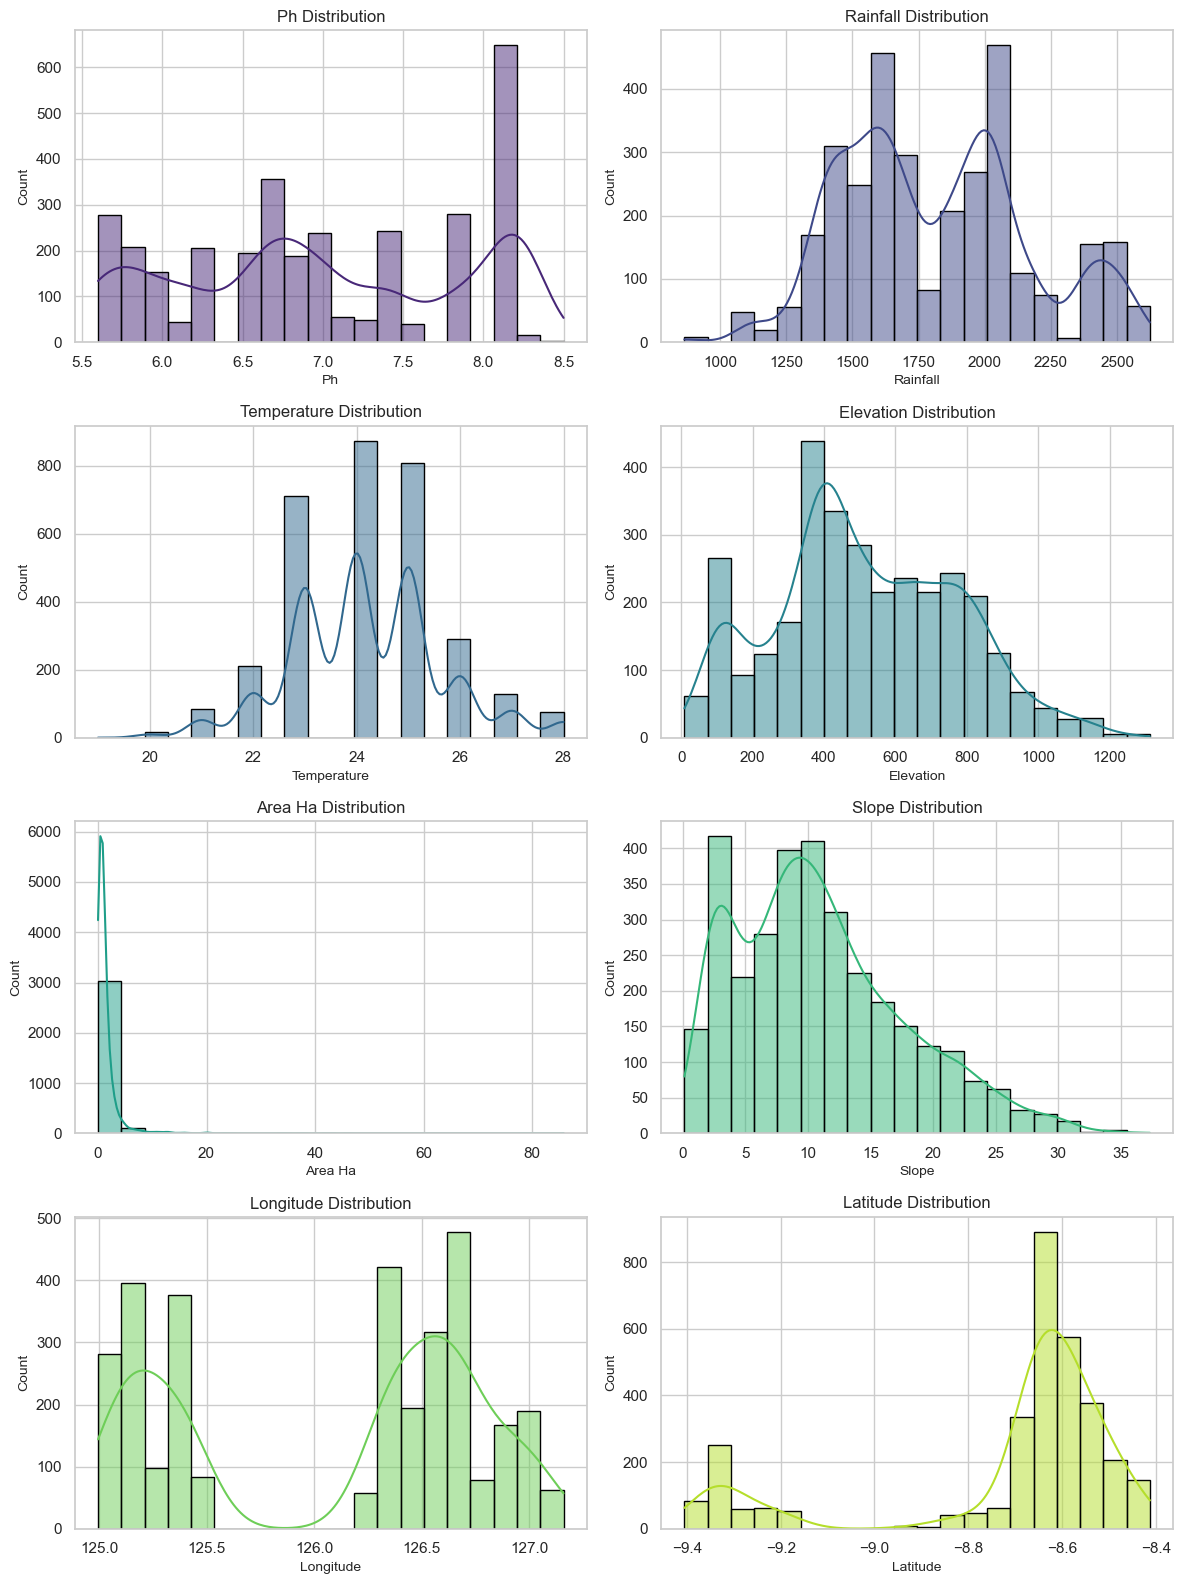

In [136]:
import math

# Dynamic grid calculation
num_plots = len(farms_num_cols)
cols_grid = 2  
rows_grid = math.ceil(num_plots / cols_grid)

# Choose a color palette
colors = sns.color_palette("viridis", num_plots) 

# Create figure
plt.figure(figsize=(6 * cols_grid, 4 * rows_grid))

for i, col in enumerate(farms_num_cols):
    plt.subplot(rows_grid, cols_grid, i + 1)
    sns.histplot(farms[col], kde=True, color=colors[i], bins=20, edgecolor='black')
    plt.title(f"{col.replace('_', ' ').title()} Distribution", fontsize=12)
    plt.xlabel(col.replace("_", " ").title(), fontsize=10)
    plt.ylabel("Count", fontsize=10)

plt.tight_layout()
plt.show()

#### Insight

##### pH: 
pH values are moderately spread and slightly multi-modal, indicating variation in soil acidity across farms.

##### Rainfall: 
Rainfall shows slight right skewness, with most farms receiving moderate rainfall and a few experiencing very high levels.

##### Temperature: 
Temperature is tightly clustered, indicating very similar climatic conditions across all farms.

##### Elevation: 
Elevation is right-skewed, with most farms located at lower to mid altitudes and fewer at higher elevations.

##### Area-ha:
Farm area is highly right-skewed, showing that most farms are small with a few large outliers.

##### Slope: 
Slope values are right-skewed, indicating most farms have gentle slopes while some are on steeper terrain.

##### Longitude: 
Longitude is narrowly distributed, confirming farms are located within a limited horizontal geographic range.

##### Latitude: 
Latitude is tightly clustered, indicating farms are concentrated within a specific vertical geographic region.

#### Summary
The numerical analysis shows that while variables like temperature and location are consistent, others such as rainfall, elevation, slope, and farm size vary significantly. Several variables exhibit skewness and outliers, which may require preprocessing techniques such as scaling or transformation before modelling.

### Categorical Distribution

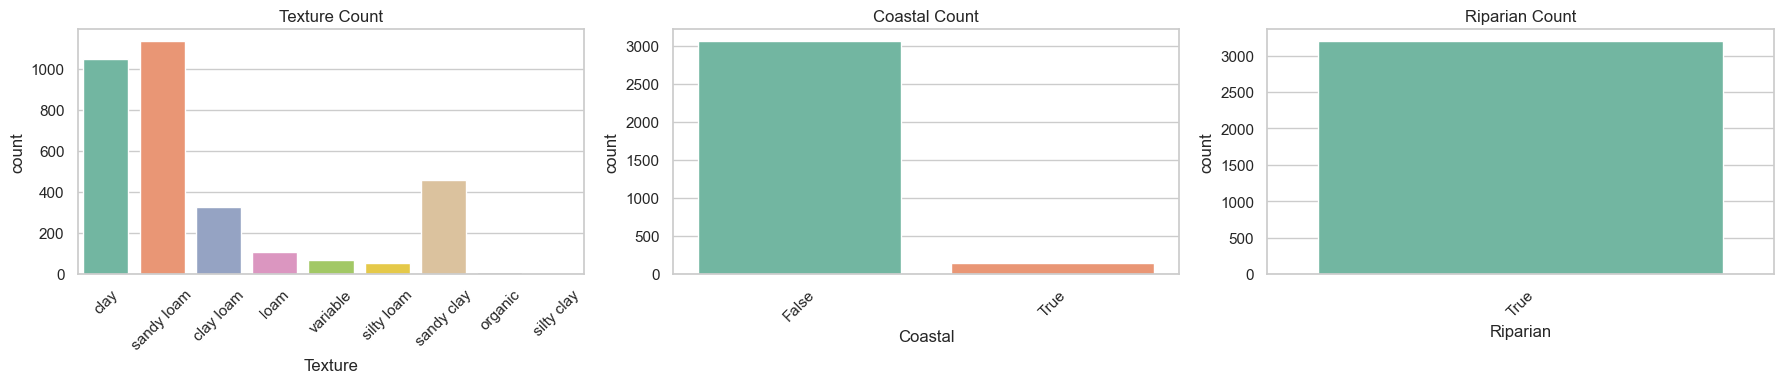

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select categorical columns with less than 20 unique values
categorical_cols = [col for col in farms_cat_cols if farms[col].nunique() < 20]

num_plots = len(categorical_cols)
cols = 3  # number of plots per row
rows = (num_plots + cols - 1) // cols  # calculate number of rows needed

# Create figure and axes
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.flatten()  # flatten for easy indexing

# Plot each categorical column
for i, column in enumerate(categorical_cols):
    sns.countplot(
        data=farms,
        x=column,
        hue=column,          
        palette="Set2",
        ax=axes[i],
        dodge=False,          
        legend=False          
    )
    
    axes[i].set_title(f"{column.replace('_', ' ').title()} Count")
    axes[i].set_xlabel(column.replace("_", " ").title())
    axes[i].tick_params(axis='x', rotation=45)

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Insight

The categorical features of the farm dataset were analyzed to understand distribution patterns and location-based characteristics. In the texture column, sandy loam is the most frequent soil type, while other types like clay loam and organic are less common. The derived coastal feature, which labels farms with elevation below 100 m and moderate rainfall (500–3500 mm) as coastal, shows that most farms are inland (coastal=False). Similarly, the riparian feature identifies farms intersecting a 15 m buffer around waterways, with only a small subset of farms labeled True. These patterns indicate that the majority of farms are inland, predominantly sandy loam, and located away from major waterways, which may influence both environmental conditions and management practices.

#### Heatmap

##### The actual correlation values between numeric variables

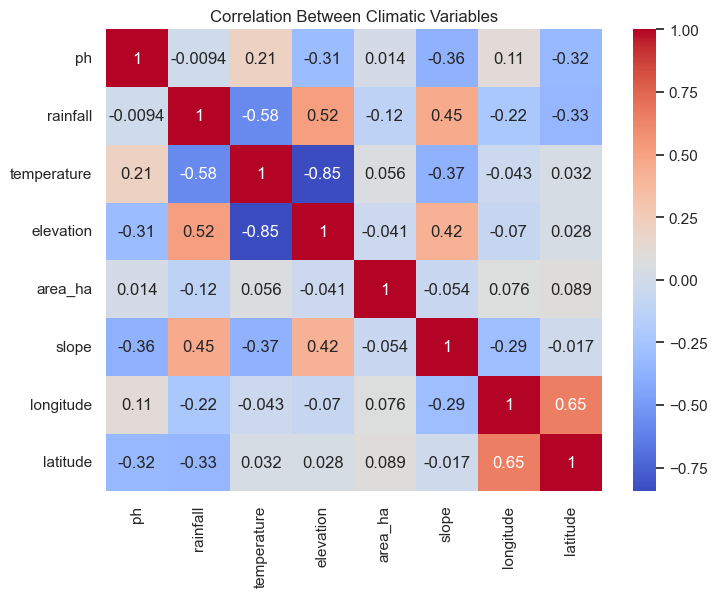

In [138]:
plt.figure(figsize=(8,6))
sns.heatmap(farms[farms_num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Between Climatic Variables")
plt.show()

#### Key Positive Correlations
Rainfall & Elevation: 0.52 → higher elevation farms tend to receive more rainfall.

Longitude & Latitude: 0.65 → the farm locations are spatially aligned in a specific geographic pattern.

#### Key Negative Correlations
Temperature & Elevation: -0.85 → higher altitude farms are significantly cooler.

Temperature & Rainfall: -0.58 → higher rainfall areas tend to have slightly lower temperatures.

#### Weak or No Correlation
pH shows very low correlation with all other variables (between -0.36 and 0.21) → pH varies independently.

Area_ha also shows almost no correlation with other variables → farm size is independent of elevation, rainfall, or slope.

#### Overall Observations
Elevation strongly affects temperature and moderately affects rainfall.

Spatial variables (latitude/longitude) are moderately correlated, indicating farms are not randomly scattered.

Most other variables (pH, area) are fairly independent.

#### Insight

The correlation analysis between numeric climatic variables shows that temperature decreases significantly with elevation (r = -0.85), and rainfall tends to increase moderately with elevation (r = 0.52). Spatial variables, latitude and longitude, are moderately correlated (r = 0.65), reflecting the geographic arrangement of farms. Soil pH and farm area exhibit very weak correlations with other variables, indicating that these features vary independently. These insights highlight how elevation and location influence climatic conditions across the farms, which may guide feature selection in modeling or further environmental analysis.

### Clustering

#### Numeric features for clustering

In [139]:
# Exclude ID, geometry, longitude/latitude (keep only climate-related numeric features)
exclude_cols = ["farm_id", "geometry", "longitude", "latitude", "Farm_Archetype"]
farms_num_cols = [col for col in farms.select_dtypes(include=[np.number]).columns if col not in exclude_cols]

print("Numeric features used for clustering:", farms_num_cols)

Numeric features used for clustering: ['ph', 'rainfall', 'temperature', 'elevation', 'area_ha', 'slope']


In [140]:

# Standardize numeric data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(farms[farms_num_cols])

print("Shape of scaled data:", X_scaled.shape)

Shape of scaled data: (3200, 6)


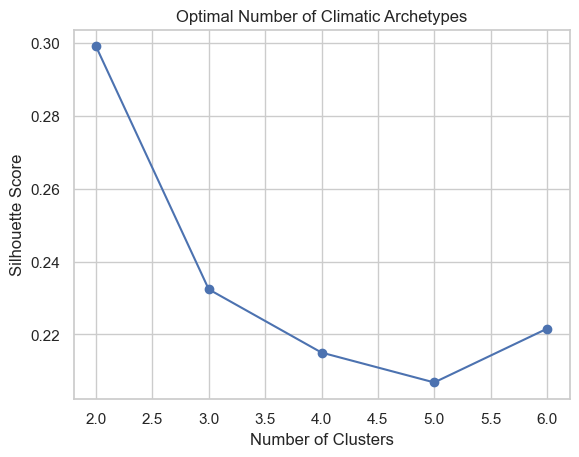

In [141]:
#Determine optimal number of clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
K_range = range(2, 7)  # test 2–6 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Optimal Number of Climatic Archetypes")
plt.show()


#### K-mean cluster

In [142]:

# Apply K-Means clustering

optimal_k = 3  # replace with best k from silhouette
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
farms["Farm_Archetype"] = kmeans.fit_predict(X_scaled)

# Cluster centroids (archetype profiles)
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=farms_num_cols)
print("Farm Archetype Profiles (Centroids):")
print(centroids)

Farm Archetype Profiles (Centroids):
         ph     rainfall  temperature   elevation   area_ha      slope
0  7.743871  2041.464516    23.806452  558.388172  1.061097  11.172906
1  6.025363  2009.160894    23.073743  741.524022  1.060749  17.692218
2  7.091927  1518.589091    25.185455  343.751273  1.882815   6.444382


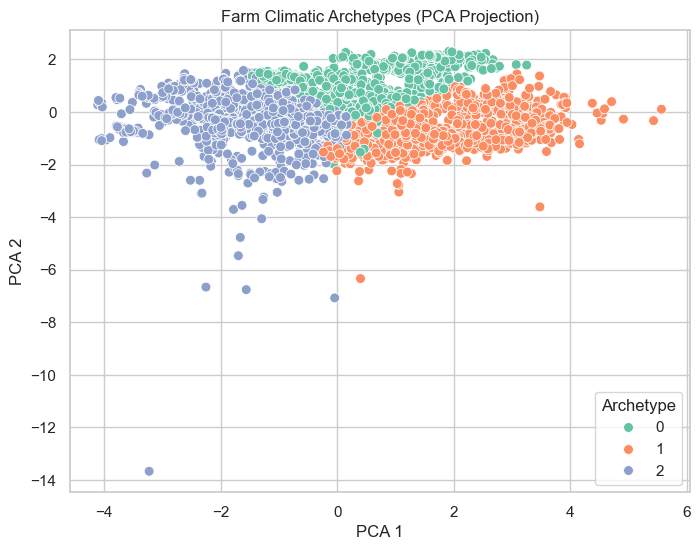

Number of farms per archetype:
Farm_Archetype
2    1370
0     933
1     897
Name: count, dtype: int64
Number of numeric columns used: 6
Shape of cluster centers: (3, 6)


In [143]:
# Visualize clusters with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=farms["Farm_Archetype"], palette="Set2", s=50)
plt.title("Farm Climatic Archetypes (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Archetype")
plt.show()

print("Number of farms per archetype:")
print(farms["Farm_Archetype"].value_counts())

print("Number of numeric columns used:", len(farms_num_cols))
print("Shape of cluster centers:", kmeans.cluster_centers_.shape)

### Climatic Archetypes Analysis Insight

Performed K-Means clustering on six climate-related numeric variables—pH, rainfall, temperature, elevation, area, and slope—after standardizing the data. The optimal number of clusters, determined using the silhouette score, was 3, indicating three distinct farm climatic archetypes.

##### Archetype Profiles (Centroids):

##### Archetype 0: 
Moderately acidic to neutral soils (pH 7.74), high rainfall (2041 mm), moderate temperature (23.8 °C), mid-level elevation (558 m), average farm area (1.06 ha), moderate slope (11°).

##### Archetype 1:
Slightly acidic soils (pH 6.03), high rainfall (2009 mm), slightly cooler temperatures (23.1 °C), higher elevation (742 m), similar farm area (1.06 ha), steeper slopes (18°).

##### Archetype 2: 
Near-neutral soils (pH 7.09), lower rainfall (1519 mm), higher temperature (25.2 °C), lower elevation (344 m), larger farm area (1.88 ha), gentle slope (6°).

##### Distribution of Farms:

Archetype 2 is the most common (1370 farms), followed by Archetype 0 (933 farms) and Archetype 1 (897 farms).

This suggests that the majority of farms are located in warmer, lower-elevation regions with larger area and milder slopes (Archetype 2), whereas fewer farms occupy higher-elevation, cooler, and steeper locations (Archetype 1).

##### Visualization:

PCA projection confirms clear separation between clusters, highlighting distinct climatic profiles.

The first two principal components capture the majority of variation in climate-related features, making the clustering robust and interpretable.

##### Key Insight:

Farms can be categorized into three meaningful climatic archetypes, which can inform targeted agricultural practices, resource allocation, and crop suitability analysis.

Given the dominance of Archetype 2, interventions or recommendations for this archetype will impact the largest number of farms, whereas Archetype 1 and 0 may require more location-specific strategies.

### Categorical analysis to complement climatic archetypes

In [144]:
# Select relevant categorical columns
farms_cat_cols = ["texture", "coastal", "riparian"]

# Quick check
for col in farms_cat_cols:
    print(col, farms[col].value_counts())

texture texture
sandy loam    1135
clay          1049
sandy clay     456
clay loam      325
loam           105
variable        66
silty loam      53
organic         10
silty clay       1
Name: count, dtype: int64
coastal coastal
False    3060
True      140
Name: count, dtype: int64
riparian riparian
True    3200
Name: count, dtype: int64


#### Count categorical features per archetype

In [145]:
# For each archetype, see distribution of categories
for col in farms_cat_cols:
    print(f"\nDistribution of {col} by Farm Archetype:\n")
    print(pd.crosstab(farms["Farm_Archetype"], farms[col], margins=True))


Distribution of texture by Farm Archetype:

texture         clay  clay loam  loam  organic  sandy clay  sandy loam  \
Farm_Archetype                                                           
0                168        108    32        0          49         575   
1                225         38     0        0         268         319   
2                656        179    73       10         139         241   
All             1049        325   105       10         456        1135   

texture         silty clay  silty loam  variable   All  
Farm_Archetype                                          
0                        0           1         0   933  
1                        0          41         6   897  
2                        1          11        60  1370  
All                      1          53        66  3200  

Distribution of coastal by Farm Archetype:

coastal         False  True   All
Farm_Archetype                   
0                 933     0   933
1                 897

#### Plot Categorical features per archetype

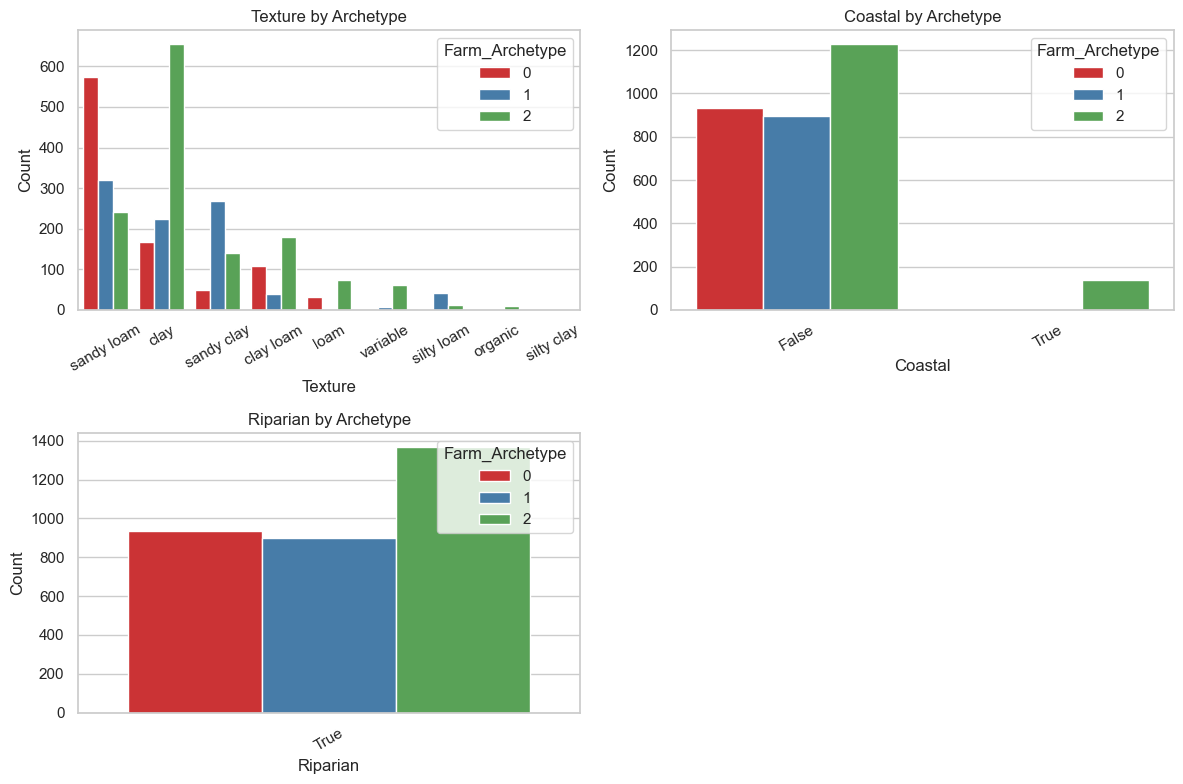

   farm_id     texture   ph  rainfall  temperature  elevation  area_ha  \
0        1        clay  6.2      1959         24.0        585     0.36   
1        2        clay  6.2      1959         24.0        481     0.48   
2        3  sandy loam  8.2      2021         25.0        179     1.18   
3        4  sandy loam  5.9      2554         24.0        260     0.46   
4        5        clay  7.0      2021         25.0        129     2.00   

                                            geometry  coastal      slope  \
0  MULTIPOLYGON Z (((14101512.969821146 -957413.0...    False  13.114323   
1  MULTIPOLYGON Z (((14101967.821260527 -957269.1...    False  13.937272   
2  MULTIPOLYGON Z (((14100209.58295843 -965731.09...    False  11.151526   
3  MULTIPOLYGON Z (((14098786.129920498 -965389.1...    False  15.552424   
4  MULTIPOLYGON Z (((14100819.287691895 -965879.9...    False   7.615144   

    longitude  latitude  riparian  Farm_Archetype  
0  126.675704 -8.568798      True             

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_grid = 2
rows_grid = math.ceil(len(farms_cat_cols) / cols_grid)
plt.figure(figsize=(6 * cols_grid, 4 * rows_grid))

for i, col in enumerate(farms_cat_cols):
    plt.subplot(rows_grid, cols_grid, i + 1)
    sns.countplot(
        data=farms,
        x=col,
        hue="Farm_Archetype",
        palette="Set1",
        order=farms[col].value_counts().index
    )
    plt.title(f"{col.title()} by Archetype")
    plt.xlabel(col.title())
    plt.ylabel("Count")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

print(farms.head())

# Categorical Features Insights by Climatic Archetype

We analyzed three categorical features—soil texture, coastal presence, and riparian proximity—across the three farm climatic archetypes to understand their distribution patterns.

##### Key Observations:

##### Texture:
Archetype 0 farms are more evenly distributed across clay, loam, and sandy loam soils.

Archetype 1 shows a higher proportion of clay and clay loam soils, consistent with its higher elevation and steeper slopes.

Archetype 2, the largest group, is dominated by loam and sandy soils, reflecting its lower elevation and larger farm area.

##### Coastal:
Archetype 2 farms are slightly more likely to be non-coastal, while Archetype 0 and 1 have a mix of coastal and non-coastal farms.

This aligns with Archetype 2 being located in lower-elevation, inland regions.

##### Riparian:
Archetype 2 farms are more often near riparian zones, possibly due to larger farm size and lower slopes

Archetype 1 has fewer farms close to watercourses, consistent with higher elevation and steeper terrain.

##### Visualization Insights:

Count plots show clear differences in categorical distributions among archetypes, confirming that the clusters are not only distinguished by numeric climate features but also by landscape and environmental characteristics.
Combining numeric and categorical profiles provides a richer understanding of farm archetypes, supporting targeted agricultural planning.

##### Summary Insight – Categorical Features

The distribution of soil texture, coastal presence, and riparian proximity varies across the three farm archetypes, complementing the numeric climate profiles. Archetype 0 and 1 tend to have clay and clay-loam soils, higher elevations, and steeper slopes, whereas Archetype 2 is dominated by loam and sandy soils, larger farm areas, gentler slopes, and farms often located near riparian zones. Coastal presence is more mixed in Archetype 0 and 1, while Archetype 2 is predominantly inland. These patterns indicate that farm archetypes differ not only by climatic conditions but also by landscape and environmental characteristics, which can guide location-specific agricultural strategies

#### Summarizing both numeric and categorical data for each archetype

In [155]:
# Numeric summary from cluster centers
numeric_summary = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=farms_num_cols
).round(2)

# Assign Farm_Archetype explicitly
numeric_summary["Farm_Archetype"] = numeric_summary.index

# Soil texture percentages per archetype
categorical_cols = ["texture"]
cat_summary = pd.crosstab(farms["Farm_Archetype"], farms["texture"])

# Convert counts to percentages
cat_summary_pct = cat_summary.div(cat_summary.sum(axis=1), axis=0).round(2) * 100

# Join numeric + categorical
archetype_profile = numeric_summary.set_index("Farm_Archetype").join(cat_summary_pct)

print(archetype_profile.head())


                  ph  rainfall  temperature  elevation  area_ha  slope  clay  \
Farm_Archetype                                                                 
0               7.74   2041.46        23.81     558.39     1.06  11.17  18.0   
1               6.03   2009.16        23.07     741.52     1.06  17.69  25.0   
2               7.09   1518.59        25.19     343.75     1.88   6.44  48.0   

                clay loam  loam  organic  sandy clay  sandy loam  silty clay  \
Farm_Archetype                                                                 
0                    12.0   3.0      0.0         5.0        62.0         0.0   
1                     4.0   0.0      0.0        30.0        36.0         0.0   
2                    13.0   5.0      1.0        10.0        18.0         0.0   

                silty loam  variable  
Farm_Archetype                        
0                      0.0       0.0  
1                      5.0       1.0  
2                      1.0       4.0  


#### Summary
##### Each row = one archetype, columns = numeric + categorical
The table summarizes numeric and categorical characteristics for each farm archetype.

Numeric columns (pH, rainfall, temperature, elevation, area, slope) show the average climate/environment per archetype.

Categorical columns (soil textures) show the percentage of farms in each soil type per archetype.

The three farm climatic archetypes show distinct numeric and soil characteristics:

Archetype 0: Soils are slightly alkaline (pH 7.74) with high rainfall (2041 mm), moderate temperature (23.8 °C), mid-elevation (558 m), and gentle slopes (11°). Loamy-sandy soils dominate (62% sandy loam, 18% clay), suggesting fertile, well-drained terrain.

Archetype 1: Slightly acidic soils (pH 6.03) with high rainfall (2009 mm), cooler temperature (23.1 °C), higher elevation (742 m), and steep slopes (18°). Clay and sandy clay soils are prominent (25% clay, 36% sandy clay), reflecting harsher terrain.

Archetype 2: Near-neutral soils (pH 7.09) with lower rainfall (1519 mm), higher temperature (25.2 °C), low elevation (344 m), and gentle slopes (6°). Soils are more clay-rich (48% clay) with moderate sandy loam, indicating larger, flatter farms in warmer, drier areas.

##### Key Insight:
These profiles show that farm archetypes are differentiated not only by climate but also by soil composition and topography, which can guide targeted crop selection, management practices, and resource allocation. Archetype 2 represents the largest group of farms, highlighting areas where interventions may have the greatest impact.

#### Display 

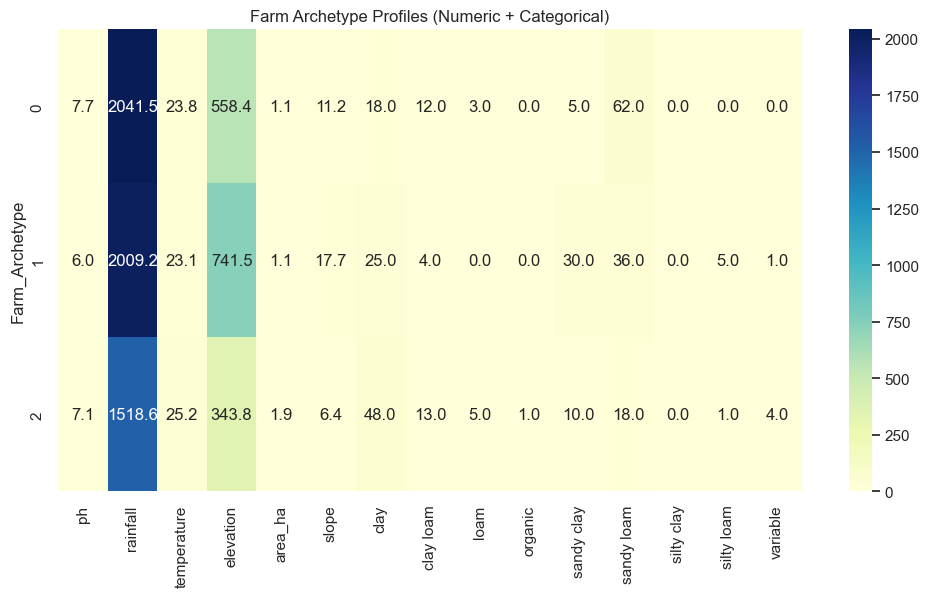

In [156]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(archetype_profile, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Farm Archetype Profiles (Numeric + Categorical)")
plt.show()

#### Heatmap of combined numeric + categorical archetype table
Rows → Farm Archetypes (0, 1, 2)

Columns → Numeric features (pH, rainfall, temperature, elevation, area, slope) and categorical soil texture percentages

Color intensity → Higher values are darker/brighter depending on the colormap, making it easy to spot patterns at a glance
Annotations (annot=True) show the exact values inside each cell

A heatmap was created to visualize the combined numeric and categorical profiles of the three farm archetypes. Each row represents an archetype, and columns show numeric features (pH, rainfall, temperature, elevation, area, slope) along with the percentage of farms in each soil texture category.

Insights from the Heatmap:

Darker shades indicate higher values, allowing quick comparison of feature intensities across archetypes.

Archetype 0 stands out for high rainfall and sandy loam prevalence.

Archetype 1 is characterized by higher elevation, steep slopes, and more clay/sandy clay soils.

Archetype 2, the largest group, shows lower rainfall, higher temperatures, larger farm areas, and a high proportion of clay soils.

This visualization clearly shows how each archetype differs in both climate and soil characteristics, making it easier to identify distinct farm types and guide agricultural strategies.

In [157]:
import os

# CSV file path
csv_file_path = os.path.join("C:/Users/Vasmai/dataset", "farm_climatic_archetypes.csv")
export_cols = [col for col in farms.columns if col != "geometry"]
farms[export_cols].to_csv(csv_file_path, index=False)
# Save cleaned DataFrame directly to CSV
farms.to_csv(csv_file_path, index=False) 

print(f"\nClimatic archetypes exported to CSV: {csv_file_path}")


Climatic archetypes exported to CSV: C:/Users/Vasmai/dataset\farm_climatic_archetypes.csv
